<a href="https://colab.research.google.com/github/anujjakhotiya/AI-DL_2026/blob/main/Lab_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 36.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.20MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 7.88MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.5MB/s]


Training samples: 60000
Testing samples: 10000

Training using Adam
Adam - Epoch 1/5 - Loss: 0.3460
Adam - Epoch 2/5 - Loss: 0.1581
Adam - Epoch 3/5 - Loss: 0.1086
Adam - Epoch 4/5 - Loss: 0.0812
Adam - Epoch 5/5 - Loss: 0.0643

Training using SGD
SGD - Epoch 1/5 - Loss: 1.2756
SGD - Epoch 2/5 - Loss: 0.5025
SGD - Epoch 3/5 - Loss: 0.3966
SGD - Epoch 4/5 - Loss: 0.3546
SGD - Epoch 5/5 - Loss: 0.3301

Evaluation Results
Adam Accuracy: 97.40%
SGD Accuracy : 91.56%


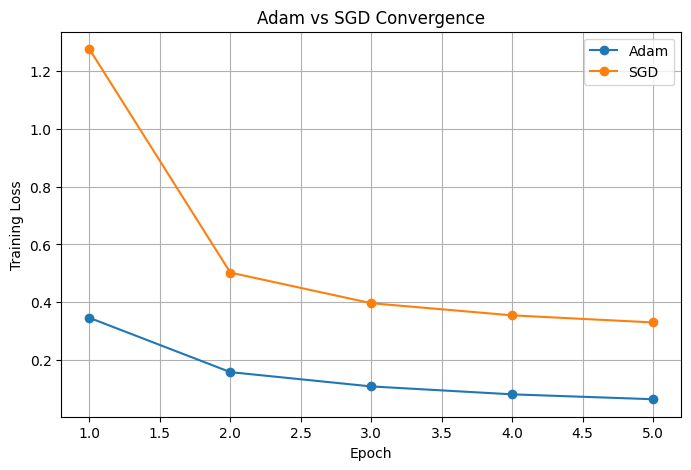

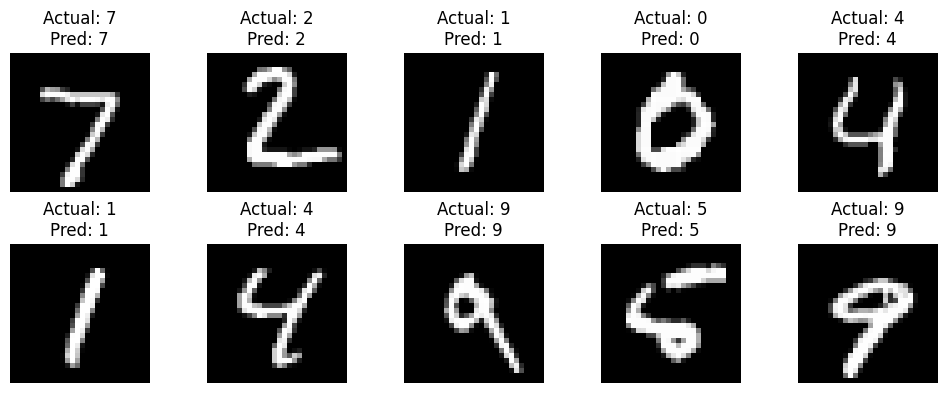

In [1]:
# Lab/Exp 5: Applying Optimizers - Adam and SGD
# MNIST Classification and Convergence Comparison

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Preprocessing
transform = transforms.ToTensor()

# Load MNIST dataset
train_data = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# Data loaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

print("Training samples:", len(train_data))
print("Testing samples:", len(test_data))


# ANN Model
class ANN(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)


# Training function
def train_model(optimizer_name):

    model = ANN().to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=0.001)
    else:
        optimizer = optim.SGD(model.parameters(), lr=0.01)

    losses = []

    for epoch in range(5):

        model.train()
        total_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            output = model(images)
            loss = criterion(output, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        losses.append(avg_loss)

        print(
            f"{optimizer_name} - Epoch {epoch + 1}/5 "
            f"- Loss: {avg_loss:.4f}"
        )

    return model, losses


# Train using Adam
print("\nTraining using Adam")
adam_model, adam_loss = train_model("Adam")


# Train using SGD
print("\nTraining using SGD")
sgd_model, sgd_loss = train_model("SGD")


# Evaluation function
def evaluate(model):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            output = model(images)

            _, predicted = torch.max(output, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total


# Evaluate models
adam_acc = evaluate(adam_model)
sgd_acc = evaluate(sgd_model)

print("\nEvaluation Results")
print(f"Adam Accuracy: {adam_acc:.2f}%")
print(f"SGD Accuracy : {sgd_acc:.2f}%")


# Compare convergence
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 6),
    adam_loss,
    marker="o",
    label="Adam"
)

plt.plot(
    range(1, 6),
    sgd_loss,
    marker="o",
    label="SGD"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Adam vs SGD Convergence")
plt.legend()
plt.grid()
plt.show()


# Display sample predictions
images, labels = next(iter(test_loader))

with torch.no_grad():
    output = adam_model(images.to(device))
    predictions = torch.argmax(output, dim=1)

plt.figure(figsize=(10, 4))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(images[i].squeeze(), cmap="gray")

    plt.title(
        f"Actual: {labels[i].item()}\n"
        f"Pred: {predictions[i].item()}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()